In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.optimize import curve_fit

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print('Usando dispositivo:', device)

Usando dispositivo: mps


In [79]:
#Carga y preparación de los datos
df = pd.read_csv('dataset_horno_fusor2.csv', parse_dates=['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)
df['error'] = df['sensor_temp'] - df['setpoint'] #Sacamos esta variable que originalmente no venía
df['sensor_temp'] = df['sensor_temp'].interpolate(method='linear')

features = ['sensor_temp', 'gas_flow', 'furnace_load', 'error', 'setpoint']
target   = 'sensor_temp'

data = df[features].dropna().values #nos deshacemos de
print('Shape del dataset:', data.shape)

Shape del dataset: (20868, 5)


In [80]:
#Todo esto es para deshacernos de los picos muy extremos para evitar meterle ruido a la hora del entrenamiento.
q_low  = df['sensor_temp'].quantile(0.01)
q_high = df['sensor_temp'].quantile(0.99)
df = df[(df['sensor_temp'] > q_low) & (df['sensor_temp'] < q_high)]

In [81]:
#Se hace el escalado de datos
LOOKBACK  = 15      #Este parámetro básicamente nos dice 15 pasos por 20 segundos. Es decir, para calcular el punto n, vamos a voltear a ver a los 5 minutos de contexto previos a n.
TRAIN_PCT = 0.8 #20% train 80% train

scaler      = StandardScaler()
data_scaled = scaler.fit_transform(data)

def make_windows(arr, lookback): #Irá haciendo las ventanas de tiempo
    X, y = [], []
    for i in range(lookback, len(arr)):
        X.append(arr[i - lookback:i])
        y.append(arr[i, 0])            #Aca vamos metiendo la temperatura de sensor del siguiente paso.
    return np.array(X), np.array(y)

X, y = make_windows(data_scaled, LOOKBACK)

#Split cronológico
split   = int(len(X) * TRAIN_PCT)
X_train = torch.tensor(X[:split], dtype=torch.float32).to(device)
y_train = torch.tensor(y[:split], dtype=torch.float32).to(device)
X_test  = torch.tensor(X[split:], dtype=torch.float32).to(device)
y_test  = torch.tensor(y[split:], dtype=torch.float32).to(device)

print('Train:', X_train.shape, '  Test:', X_test.shape)

Train: torch.Size([16682, 15, 5])   Test: torch.Size([4171, 15, 5])


In [82]:
#A partir de aquí ya es construcción del modelo.
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=0.2)
        self.fc   = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze()

model     = LSTMModel(input_size=len(features)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()
print(model)

LSTMModel(
  (lstm): LSTM(5, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


Epoch 10/50  Loss: 4.6016
Epoch 20/50  Loss: 4.1749
Epoch 30/50  Loss: 4.1009
Epoch 40/50  Loss: 4.0526
Epoch 50/50  Loss: 4.0934


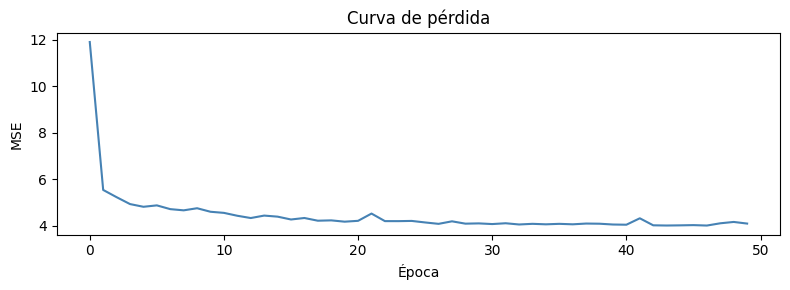

In [83]:
#Se entrena el modelo!!
EPOCHS     = 50 #Acá escogimos 50 tanteando, pero más adelante nos damos cuenta de que no valían la pena tantas épocas
BATCH_SIZE = 64
losses     = []

for epoch in range(EPOCHS):
    model.train()
    perm       = torch.randperm(X_train.size(0))
    epoch_loss = 0

    for i in range(0, X_train.size(0), BATCH_SIZE):
        idx    = perm[i:i + BATCH_SIZE]
        xb, yb = X_train[idx], y_train[idx]
        optimizer.zero_grad()
        pred   = model(xb)
        loss   = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    losses.append(epoch_loss)
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/{EPOCHS}  Loss: {epoch_loss:.4f}')

plt.figure(figsize=(8, 3))
plt.plot(losses, color='steelblue')
plt.title('Curva de pérdida')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.tight_layout()

RMSE: 4.8432 °C
MAE : 3.0074 °C


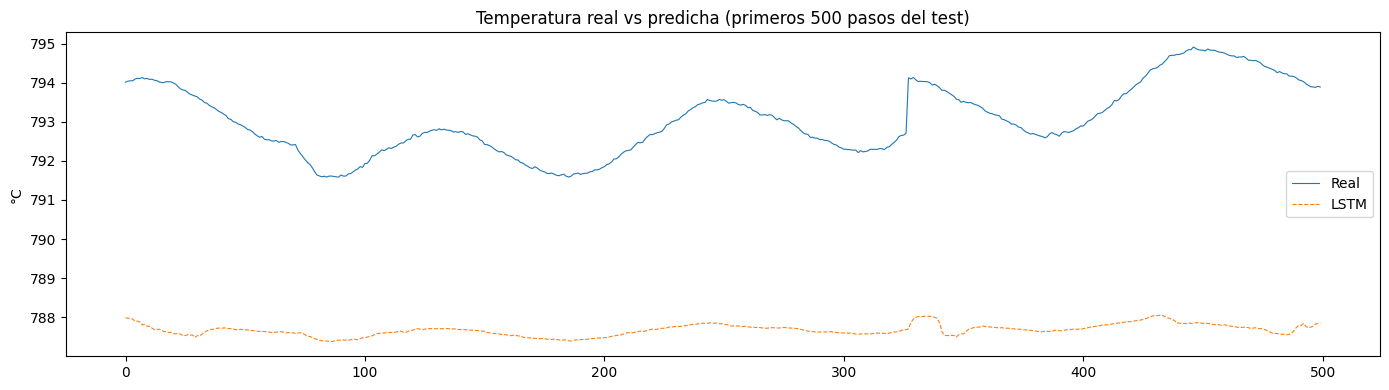

In [84]:
#En este bloque de códgio, lo que se hace es comparar las temperaturas predichas por el modelo vs las temperaturas reales del set de validación, además de sacar las métricas de RMSE y MAE.
model.eval()
with torch.no_grad():
    pred_scaled = model(X_test).cpu().numpy()
    real_scaled = y_test.cpu().numpy()

# Desnormalizar solo sensor_temp (índice 0)
mean_temp = scaler.mean_[0]
std_temp  = scaler.scale_[0]
pred_temp = pred_scaled * std_temp + mean_temp
real_temp = real_scaled * std_temp + mean_temp

rmse = np.sqrt(mean_squared_error(real_temp, pred_temp))
mae  = mean_absolute_error(real_temp, pred_temp)
print(f'RMSE: {rmse:.4f} °C')
print(f'MAE : {mae:.4f} °C')

plt.figure(figsize=(14, 4))
plt.plot(real_temp[:500], label='Real', lw=0.8)
plt.plot(pred_temp[:500], label='LSTM', lw=0.8, linestyle='--')
plt.title('Temperatura real vs predicha (primeros 500 pasos del test)')
plt.ylabel('°C')
plt.legend()
plt.tight_layout()

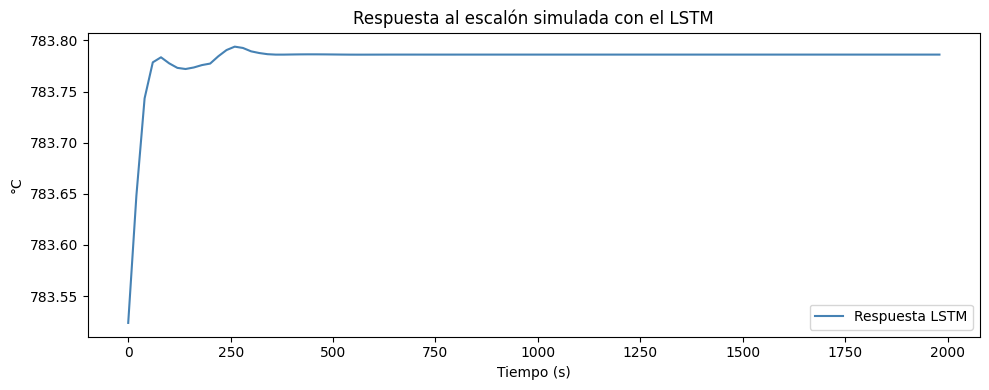

In [85]:
#Metemos un escalón para poder extraer la función de transferencia.
baseline_idx = 1000
baseline     = data_scaled[baseline_idx - LOOKBACK:baseline_idx].copy()

# Aplicamos un escalón en el setpoint. Más adelante nos dimos cuenta de que el escalón debía aplicarse a la planta, pero como este modelo era solo baseline, y nos importaba más la precisión para predecir temperaturas obtenidas, ya no hicimos cambios.
step_size    = 5 / std_temp
step_input   = baseline.copy()
step_input[:, 4] += step_size

#Simulamos 100 pasos hacia adelante
N_STEPS  = 100
response = []
window   = step_input.copy()

model.eval()
with torch.no_grad():
    for _ in range(N_STEPS):
        x_in  = torch.tensor(window[np.newaxis], dtype=torch.float32).to(device)
        y_hat = model(x_in).item()
        response.append(y_hat * std_temp + mean_temp)
        new_row       = window[-1].copy()
        new_row[0]    = y_hat
        window        = np.vstack([window[1:], new_row])

t_step = np.arange(N_STEPS) * 20

plt.figure(figsize=(10, 4))
plt.plot(t_step, response, color='steelblue', lw=1.5, label='Respuesta LSTM')
plt.xlabel('Tiempo (s)')
plt.ylabel('°C')
plt.title('Respuesta al escalón simulada con el LSTM')
plt.legend()
plt.tight_layout()

Ganancia  K  : 0.2620 °C/°C
Constante tau: 16.4 s  (0.27 min)
Retardo   L  : 9.4 s  (0.16 min)


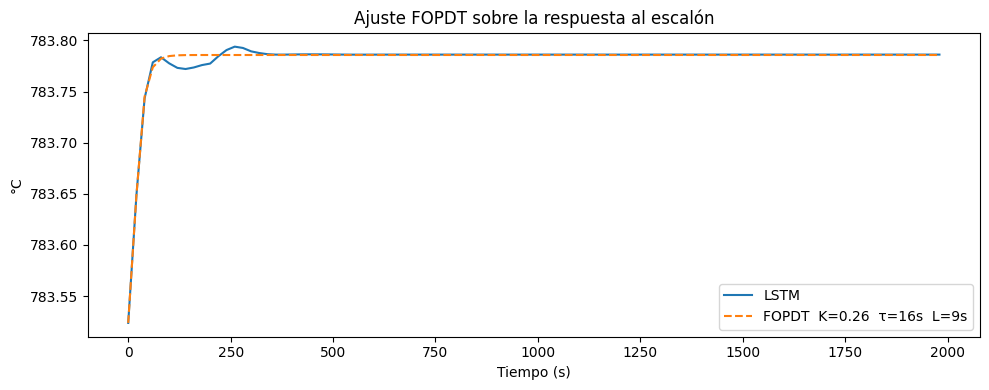

In [86]:
#Ajustamos una FOPDT, que nos permitirá extraer la ganancia K, la constante tau y el retardo L
y0    = response[0]
y_inf = response[-1]

def fopdt(t, K, tau, L):
    y = np.where(t < L, y0, y0 + K * (1 - np.exp(-(t - L) / tau)))
    return y

try:
    popt, _ = curve_fit(fopdt, t_step, response,
                        p0=[y_inf - y0, 100, 20],
                        bounds=([0, 1, 0], [100, 2000, 300]))
    K_est, tau_est, L_est = popt
    print(f'Ganancia  K  : {K_est:.4f} °C/°C')
    print(f'Constante tau: {tau_est:.1f} s  ({tau_est/60:.2f} min)')
    print(f'Retardo   L  : {L_est:.1f} s  ({L_est/60:.2f} min)')

    plt.figure(figsize=(10, 4))
    plt.plot(t_step, response, label='LSTM', lw=1.5)
    plt.plot(t_step, fopdt(t_step, *popt), '--', label=f'FOPDT  K={K_est:.2f}  τ={tau_est:.0f}s  L={L_est:.0f}s', lw=1.5)
    plt.xlabel('Tiempo (s)')
    plt.ylabel('°C')
    plt.title('Ajuste FOPDT sobre la respuesta al escalón')
    plt.legend()
    plt.tight_layout()

except Exception as e:
    print('El ajuste no convergió:', e)
    print('Intenta ajustar p0 o bounds manualmente.')